In [161]:
import csv
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [162]:
# read data

df = pd.read_csv('src/cancer.data', skiprows=2, header=None)

X = df.iloc[:, :-1] # everything except last column
y = df.iloc[:, -1] # last col
y = y.replace({1: 0, 2: 1})

In [163]:

# using state=42 makes result reproducable. remove for random
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

# scale the values
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# note -> values are close so no need to scale. same answer. but we scale anyways

# verify shape
print(X_train.shape)
print(X_test.shape)

(274, 9)
(183, 9)


In [164]:
y_train = y_train.values
y_test = y_test.values

X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

print(y_train.shape)
print(X_train.shape)

(274,)
(274, 10)


In [165]:
# need a weight for all inputs
# need w0 (bias)
weights = np.zeros(X_train.shape[1])
allLoss = []

prev_loss = 0
current_loss = 0
threshold = 1e-5

fail_safe = 5000
iterations = 0
learning_rate = 0.08
epsilon = 1e-15 # const dont change

while iterations < fail_safe:
    # 1. predict
    z = np.dot(X_train, weights)
    y_pred = sigmoid(z)

    # 2. calculate loss
    m = len(y_train)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    current_loss = -(1/m) * np.sum(
        y_train * np.log(y_pred) + (1 - y_train) * np.log(1 - y_pred)
    )
    allLoss.append(current_loss)

    # 3. stop if converged
    if iterations > 0 and abs(current_loss - prev_loss) < threshold:
        print(f"Iterations: {iterations} | current_loss: {current_loss}")
        break

    # 4. check error
    error = y_pred - y_train

    # 5. adjust weight
    gradient = np.dot(X_train.T, error) / m
    weights = weights - learning_rate * gradient

    # 6. update for next loop
    prev_loss = current_loss
    iterations += 1

print(f"Iterations: {iterations} | current_loss: {current_loss}")

Iterations: 1087 | current_loss: 0.0554050502033656
Iterations: 1087 | current_loss: 0.0554050502033656


In [166]:
# run the algo again but on test data
z_test = np.dot(X_test, weights)
y_prob = sigmoid(z_test)

# change probability into class label. Threshold is 0.5
y_pred = (y_prob >= 0.5).astype(int)

# compare accuracy
accuracy = np.mean(y_pred == y_test)

print(f"Accurary: {accuracy}")

Accurary: 0.9672131147540983


In [167]:
print("weights:")

for i, w in enumerate(weights):
    print(f"    w{i}: {w}")

weights:
    w0: -0.7414739494481758
    w1: 1.248679048567483
    w2: 0.283340233732981
    w3: 0.5682043170237921
    w4: 0.9681247230602746
    w5: 0.8461521871133221
    w6: 1.5043918005504402
    w7: 0.9798059048617892
    w8: 0.49673127337361744
    w9: 0.8594455893821804


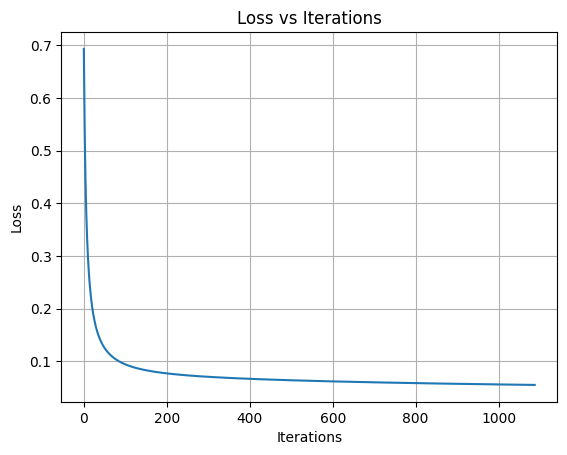

In [168]:
# plot
# create x-axis (iterations)
iterations = list(range(len(allLoss)))

# plot
plt.figure()
plt.plot(iterations, allLoss)

# labels
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")

# show grid (optional but helpful)
plt.grid()

plt.show()